# 🥦 Klasifikasi Kesegaran Sayur & Buah
## Phase 2 — Fine-Tuning MobileNetV2

Melanjutkan dari Phase 1 (Feature Extraction, Test Accuracy: **91.93%**).  
Phase ini membuka layer-layer atas backbone MobileNetV2 agar model bisa menyesuaikan fitur domain-spesifik.

**Tujuan utama:**
- Tingkatkan overall accuracy (target ≥ 94%)
- Perbaiki kelas-kelas lemah: `Mangga_Terlalu Matang` (F1: 0.50), `Anggur_Matang` (F1: 0.58), `Jeruk_Terlalu Matang` (F1: 0.72)

| Fase | Metode | LR | Status |
|---|---|---|---|
| Phase 1 | Feature Extraction (frozen backbone) | 1e-3 | ✅ Selesai |
| Phase 2 | Fine-Tuning (unfreeze 30 layer terakhir) | 1e-5 | ▶️ Sekarang |

## 1. Setup & Load Dependensi

In [ ]:
import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import shutil, zipfile
from google.colab import drive

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
)
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import Sequence, to_categorical

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow  :", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))

TensorFlow  : 2.20.0
GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Mount Drive & Load Konfigurasi Phase 1

In [ ]:
drive.mount('/content/drive')

# Path 
DATASET_DIR     = "/content/sayur_buah_gambar"
PHASE1_MODEL    = "checkpoints/best_model.keras"   # hasil Phase 1
METADATA_PATH   = "model_metadata.json"

# Hyperparameter Phase 2
IMG_SIZE        = 224
BATCH_SIZE      = 32
VAL_SPLIT       = 0.15
TEST_SPLIT      = 0.15
EPOCHS_FT       = 30          # max epoch; early stopping akan berhenti lebih awal
LR_FT           = 1e-5        # HARUS jauh lebih kecil dari Phase 1
UNFREEZE_LAYERS = 30          # jumlah layer terakhir backbone yang dibuka
MAX_PER_CLASS   = 1500

CONFIDENCE_THRESHOLD = 0.60
ENTROPY_THRESHOLD    = 1.134

# Label mapping (sama dengan Phase 1)
KONDISI_MAP = {
    ('buah', 'unripe')   : ('Buah', 'Mentah'),
    ('buah', 'ripe')     : ('Buah', 'Matang'),
    ('buah', 'overripe') : ('Buah', 'Terlalu Matang'),
    ('buah', 'rotten')   : ('Buah', 'Busuk'),
    ('sayur', 'fresh')   : ('Sayur', 'Segar'),
    ('sayur', 'rotten')  : ('Sayur', 'Busuk'),
}
NAMA_ITEM_MAP = {
    'apple'  : 'Apel',    'banana' : 'Pisang',
    'mango'  : 'Mangga',  'orange' : 'Jeruk',
    'carrot' : 'Wortel',  'potato' : 'Kentang',
    'cabe'   : 'Cabai',   'grape'  : 'Anggur',
    'timun'  : 'Mentimun','tomat'  : 'Tomat',
}

print("Konfigurasi Phase 2:")
print(f"  LR Fine-Tuning   : {LR_FT}")
print(f"  Unfreeze layers  : {UNFREEZE_LAYERS} layer terakhir backbone")
print(f"  Max epochs       : {EPOCHS_FT}")
print(f"  Phase 1 model    : {PHASE1_MODEL}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Konfigurasi Phase 2:
  LR Fine-Tuning   : 1e-05
  Unfreeze layers  : 30 layer terakhir backbone
  Max epochs       : 30
  Phase 1 model    : checkpoints/best_model.keras


## 3. Rebuild Dataset (sama persis dengan Phase 1)

In [ ]:
# Extract dataset jika belum ada
ZIP_PATH  = "/content/drive/MyDrive/sayur_buah_gambar.zip"
LOCAL_DIR = "/content/sayur_buah_gambar"

if not os.path.exists(LOCAL_DIR):
    print("Menyalin zip dari Drive ke lokal...")
    shutil.copy(ZIP_PATH, "/content/sayur_buah_gambar.zip")
    print("Mengekstrak...")
    with zipfile.ZipFile("/content/sayur_buah_gambar.zip") as z:
        z.extractall("/content/")
    print("Selesai!")
else:
    print("Dataset sudah ada di lokal, skip copy.")

Dataset sudah ada di lokal, skip copy.


In [ ]:
# Scan dataset (identik dengan Phase 1) 
dataset_path  = Path(DATASET_DIR)
extensions    = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

all_paths, all_labels, all_meta = [], [], []
label_counts  = defaultdict(int)
label_skipped = defaultdict(int)

for jenis_dir in ['buah', 'sayur']:
    jenis_path = dataset_path / jenis_dir
    if not jenis_path.exists():
        print(f"[WARN] Folder tidak ditemukan: {jenis_path}")
        continue
    for kondisi_folder in sorted(jenis_path.iterdir()):
        if not kondisi_folder.is_dir(): continue
        kondisi_key = kondisi_folder.name.lower()
        map_key = (jenis_dir, kondisi_key)
        if map_key not in KONDISI_MAP: continue
        jenis_std, kondisi_std = KONDISI_MAP[map_key]
        for item_folder in sorted(kondisi_folder.iterdir()):
            if not item_folder.is_dir(): continue
            raw_name  = item_folder.name.lower()
            nama_item = raw_name
            for suffix in ['_unripe','_ripe','_overripe','_rotten','_fresh']:
                nama_item = nama_item.replace(suffix, '')
            nama_item_indo = NAMA_ITEM_MAP.get(nama_item, nama_item.title())
            imgs  = [f for f in item_folder.iterdir() if f.suffix in extensions]
            label = f"{nama_item_indo}||{jenis_std}||{kondisi_std}"
            if len(imgs) > MAX_PER_CLASS:
                random.shuffle(imgs)
                label_skipped[label] += len(imgs) - MAX_PER_CLASS
                imgs = imgs[:MAX_PER_CLASS]
            for img_path in imgs:
                all_paths.append(str(img_path))
                all_labels.append(label)
                all_meta.append({'nama': nama_item_indo, 'jenis': jenis_std, 'kondisi': kondisi_std})
            label_counts[label] += len(imgs)

CLASS_NAMES = sorted(set(all_labels))
NUM_CLASSES = len(CLASS_NAMES)
label2idx   = {l: i for i, l in enumerate(CLASS_NAMES)}
idx2label   = {i: l for l, i in label2idx.items()}

print(f"Total gambar : {len(all_paths):,}")
print(f"Total kelas  : {NUM_CLASSES}")

Total gambar : 24,786
Total kelas  : 30


In [ ]:
# Split data (seed sama = split identik dengan Phase 1)
paths  = np.array(all_paths)
labels = np.array(all_labels)

X_temp, X_test, y_temp, y_test = train_test_split(
    paths, labels, test_size=TEST_SPLIT, stratify=labels, random_state=SEED
)
val_ratio = VAL_SPLIT / (1 - TEST_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio, stratify=y_temp, random_state=SEED
)

y_train_idx = np.array([label2idx[l] for l in y_train])
y_val_idx   = np.array([label2idx[l] for l in y_val])
y_test_idx  = np.array([label2idx[l] for l in y_test])

print(f"Train : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")

Train : 17,350
Val   : 3,718
Test  : 3,718


In [ ]:
# tf.data pipeline 
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment_fn(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_crop(img, size=[int(IMG_SIZE * 0.9), int(IMG_SIZE * 0.9), 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
    img = tf.image.random_saturation(img, lower=0.85, upper=1.15)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def make_dataset(paths, labels_idx, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels_idx.astype('int32')))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train_idx, augment=True,  shuffle=True)
val_ds   = make_dataset(X_val,   y_val_idx,   augment=False, shuffle=False)
test_ds  = make_dataset(X_test,  y_test_idx,  augment=False, shuffle=False)

# Class weight
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train_idx
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}

print(f"Pipeline siap — train batches: {len(train_ds)}")

Pipeline siap — train batches: 543


## 4. Load Model Phase 1 & Setup Fine-Tuning

In [ ]:
# Load best model dari Phase 1
print(f"Memuat model Phase 1 dari: {PHASE1_MODEL}")
model = keras.models.load_model(PHASE1_MODEL)

# Temukan backbone MobileNetV2
base_model = None
for layer in model.layers:
    if isinstance(layer, keras.Model) and 'mobilenet' in layer.name.lower():
        base_model = layer
        break

if base_model is None:
    raise ValueError("Backbone MobileNetV2 tidak ditemukan dalam model!")

print(f"Backbone ditemukan : {base_model.name}")
print(f"Total layer backbone: {len(base_model.layers)}")
print(f"\nStatus sebelum fine-tuning:")
print(f"  Trainable layers : {sum(1 for l in model.layers if l.trainable)}")
print(f"  Frozen layers    : {sum(1 for l in model.layers if not l.trainable)}")

Memuat model Phase 1 dari: checkpoints/best_model.keras
Backbone ditemukan : mobilenetv2_1.00_224
Total layer backbone: 154

Status sebelum fine-tuning:
  Trainable layers : 6
  Frozen layers    : 1


In [ ]:
# Unfreeze N layer terakhir backbone
base_model.trainable = True

# Freeze semua kecuali UNFREEZE_LAYERS layer terakhir
for layer in base_model.layers[:-UNFREEZE_LAYERS]:
    layer.trainable = False

# Hitung trainable params
trainable_count   = sum(np.prod(w.shape) for w in model.trainable_weights)
untrainable_count = sum(np.prod(w.shape) for w in model.non_trainable_weights)

print(f"Fine-Tuning config:")
print(f"  Unfreeze {UNFREEZE_LAYERS} layer terakhir backbone")
print(f"  Trainable params   : {trainable_count:,}")
print(f"  Non-trainable params: {untrainable_count:,}")
print()

# Tampilkan layer mana yang trainable/frozen
print("Layer backbone (10 terakhir yang dibuka):")
for layer in base_model.layers[-UNFREEZE_LAYERS:][-10:]:
    print(f"  [TRAINABLE] {layer.name}")

# Compile dengan LR sangat kecil
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FT),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\nModel dikompilasi ulang dengan LR = {LR_FT}")

Fine-Tuning config:
  Unfreeze 30 layer terakhir backbone
  Trainable params   : 1,862,046
  Non-trainable params: 731,584

Layer backbone (10 terakhir yang dibuka):
  [TRAINABLE] block_16_expand_BN
  [TRAINABLE] block_16_expand_relu
  [TRAINABLE] block_16_depthwise
  [TRAINABLE] block_16_depthwise_BN
  [TRAINABLE] block_16_depthwise_relu
  [TRAINABLE] block_16_project
  [TRAINABLE] block_16_project_BN
  [TRAINABLE] Conv_1
  [TRAINABLE] Conv_1_bn
  [TRAINABLE] out_relu

Model dikompilasi ulang dengan LR = 1e-05


## 5. Training Phase 2 — Fine-Tuning

In [ ]:
os.makedirs('checkpoints_ft', exist_ok=True)
os.makedirs('logs', exist_ok=True)

callbacks_ft = [
    # Simpan model terbaik berdasarkan val_loss
    ModelCheckpoint(
        filepath='checkpoints_ft/best_model_ft.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    # Hentikan training jika val_loss tidak membaik
    EarlyStopping(
        monitor='val_loss',
        patience=7,           # lebih pendek dari Phase 1 karena fine-tuning lebih stabil
        restore_best_weights=True,
        verbose=1
    ),
    # Turunkan LR jika plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    # Simpan log ke CSV untuk analisis
    CSVLogger('logs/training_ft_log.csv', append=False)
]

print("=" * 60)
print("MULAI TRAINING PHASE 2 — FINE-TUNING")
print("=" * 60)
print(f"  Model       : MobileNetV2 (unfreeze {UNFREEZE_LAYERS} layer terakhir)")
print(f"  LR          : {LR_FT}")
print(f"  Max Epochs  : {EPOCHS_FT}")
print(f"  Batch Size  : {BATCH_SIZE}")
print(f"  Class Weight: aktif (balanced)")
print("=" * 60)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FT,
    callbacks=callbacks_ft,
    class_weight=class_weight_dict,
    verbose=1
)

MULAI TRAINING PHASE 2 — FINE-TUNING
  Model       : MobileNetV2 (unfreeze 30 layer terakhir)
  LR          : 1e-05
  Max Epochs  : 30
  Batch Size  : 32
  Class Weight: aktif (balanced)
Epoch 1/30
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.6567 - loss: 1.3821
Epoch 1: val_loss improved from None to 0.22479, saving model to checkpoints_ft/best_model_ft.keras

Epoch 1: finished saving model to checkpoints_ft/best_model_ft.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 206s 313ms/step - accuracy: 0.7220 - loss: 0.9952 - val_accuracy: 0.9242 - val_loss: 0.2248 - learning_rate: 1.0000e-05
Epoch 2/30
542/543 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.8140 - loss: 0.5169
Epoch 2: val_loss did not improve from 0.22479
543/543 ━━━━━━━━━━━━━━━━━━━━ 108s 199ms/step - accuracy: 0.8255 - loss: 0.4911 - val_accuracy: 0.9177 - val_loss: 0.2400 - learning_rate: 1.0000e-05
Epoch 3/30
542/543 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8458 - loss: 0.4140
Epoch 3: val_loss did not improve 

## 6. Visualisasi Kurva Training Phase 2

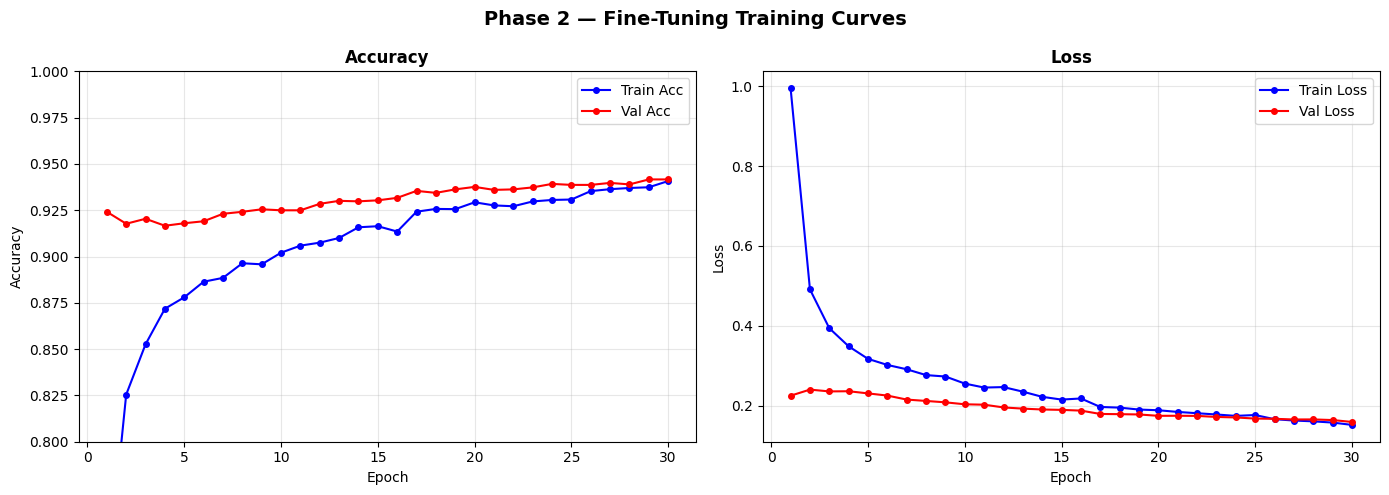

Tersimpan: ft_training_curves.png


In [ ]:
# Plot kurva Accuracy & Loss Phase 2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phase 2 — Fine-Tuning Training Curves', fontsize=14, fontweight='bold')

epochs_ran = range(1, len(history_ft.history['accuracy']) + 1)

# Accuracy
ax = axes[0]
ax.plot(epochs_ran, history_ft.history['accuracy'],     'b-o', ms=4, label='Train Acc')
ax.plot(epochs_ran, history_ft.history['val_accuracy'], 'r-o', ms=4, label='Val Acc')
ax.set_title('Accuracy', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0.8, 1.0])

# Loss
ax = axes[1]
ax.plot(epochs_ran, history_ft.history['loss'],     'b-o', ms=4, label='Train Loss')
ax.plot(epochs_ran, history_ft.history['val_loss'], 'r-o', ms=4, label='Val Loss')
ax.set_title('Loss', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ft_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tersimpan: ft_training_curves.png")

In [ ]:
# Perbandingan Phase 1 vs Phase 2 (dari CSV log Phase 1)
# Catatan: jika tidak ada CSV Phase 1, blok ini akan skip otomatis

P1_CSV = 'logs/training_p1_log.csv'   # ganti path sesuai Phase 1 kamu

if os.path.exists(P1_CSV):
    df_p1 = pd.read_csv(P1_CSV)
    df_ft = pd.DataFrame(history_ft.history)
    df_ft['epoch'] = np.arange(1, len(df_ft) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Perbandingan Phase 1 vs Phase 2', fontsize=14, fontweight='bold')

    for ax, metric, ylabel in zip(
        axes,
        [('accuracy', 'val_accuracy'), ('loss', 'val_loss')],
        ['Accuracy', 'Loss']
    ):
        train_m, val_m = metric
        ep_p1 = np.arange(1, len(df_p1) + 1)
        ep_ft = np.arange(len(df_p1) + 1, len(df_p1) + len(df_ft) + 1)

        ax.plot(ep_p1, df_p1[train_m], 'b-',  alpha=0.6, label='Train Phase 1')
        ax.plot(ep_p1, df_p1[val_m],   'r-',  alpha=0.6, label='Val Phase 1')
        ax.plot(ep_ft, df_ft[train_m], 'b--', alpha=0.9, label='Train Phase 2', lw=2)
        ax.plot(ep_ft, df_ft[val_m],   'r--', alpha=0.9, label='Val Phase 2',   lw=2)
        ax.axvline(len(df_p1), color='gray', ls=':', lw=1.5, label='Start Fine-Tuning')
        ax.set_title(ylabel, fontweight='bold')
        ax.set_xlabel('Epoch (kumulatif)')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('phase_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Tersimpan: phase_comparison.png")
else:
    print(f"[INFO] File {P1_CSV} tidak ditemukan — skip perbandingan Phase 1 vs 2.")
    print("       Jika ingin perbandingan, tambahkan CSVLogger di Phase 1 dan update path di atas.")

[INFO] File logs/training_p1_log.csv tidak ditemukan — skip perbandingan Phase 1 vs 2.
       Jika ingin perbandingan, tambahkan CSVLogger di Phase 1 dan update path di atas.


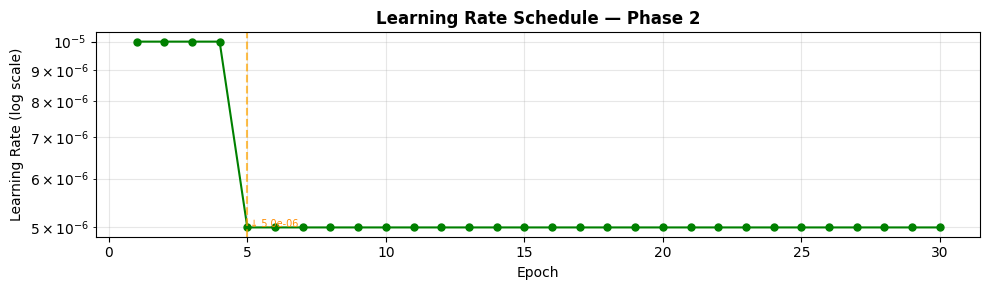

Tersimpan: ft_lr_schedule.png


In [ ]:
# Learning Rate Tracker (dari ReduceLROnPlateau)
if 'learning_rate' in history_ft.history:
    fig, ax = plt.subplots(figsize=(10, 3))
    lr_vals  = history_ft.history['learning_rate']
    ep_range = range(1, len(lr_vals) + 1)

    ax.semilogy(ep_range, lr_vals, 'g-o', ms=5)
    ax.set_title('Learning Rate Schedule — Phase 2', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate (log scale)')
    ax.grid(True, which='both', alpha=0.3)

    # Tandai setiap kali LR turun
    for i in range(1, len(lr_vals)):
        if lr_vals[i] < lr_vals[i - 1]:
            ax.axvline(i + 1, color='orange', ls='--', alpha=0.7)
            ax.text(i + 1.1, lr_vals[i], f'↓ {lr_vals[i]:.1e}', fontsize=7, color='darkorange')

    plt.tight_layout()
    plt.savefig('ft_lr_schedule.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Tersimpan: ft_lr_schedule.png")

## 7. Evaluasi Model Phase 2

In [ ]:
# Evaluasi test set
print("Mengevaluasi model terbaik Phase 2 di test set...")
model_best = keras.models.load_model('checkpoints_ft/best_model_ft.keras')

test_loss, test_acc = model_best.evaluate(test_ds, verbose=1)

# Dapatkan prediksi
y_pred_proba = model_best.predict(test_ds, verbose=1)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = y_test_idx

print(f"\n{'='*60}")
print(f"HASIL EVALUASI PHASE 2")
print(f"{'='*60}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc*100:.2f}%")

# Bandingkan dengan Phase 1
P1_ACC  = 0.9193   # ganti dengan nilai aktual Phase 1 kamu
P1_LOSS = 0.2659
delta_acc  = (test_acc - P1_ACC) * 100
delta_loss = test_loss - P1_LOSS
print(f"\n  vs Phase 1:")
print(f"  Δ Accuracy    : {delta_acc:+.2f}%")
print(f"  Δ Loss        : {delta_loss:+.4f}")
print(f"{'='*60}")

Mengevaluasi model terbaik Phase 2 di test set...
117/117 ━━━━━━━━━━━━━━━━━━━━ 25s 159ms/step - accuracy: 0.9357 - loss: 0.1694
117/117 ━━━━━━━━━━━━━━━━━━━━ 23s 151ms/step

HASIL EVALUASI PHASE 2
  Test Loss     : 0.1694
  Test Accuracy : 93.57%

  vs Phase 1:
  Δ Accuracy    : +1.64%
  Δ Loss        : -0.0965


In [ ]:
# Classification Report
short_names = [c.replace('||Buah||', '_').replace('||Sayur||', '_').replace('||', '_')
               for c in CLASS_NAMES]

report_str  = classification_report(y_true, y_pred, target_names=short_names)
report_dict = classification_report(y_true, y_pred, target_names=short_names, output_dict=True)

print("=" * 70)
print("CLASSIFICATION REPORT — PHASE 2")
print("=" * 70)
print(report_str)

CLASSIFICATION REPORT — PHASE 2
                       precision    recall  f1-score   support

         Anggur_Busuk       0.95      0.80      0.87        91
        Anggur_Matang       0.56      0.88      0.68        17
        Anggur_Mentah       0.68      0.79      0.73        34
Anggur_Terlalu Matang       0.85      0.89      0.87        19
           Apel_Busuk       0.99      0.93      0.96       225
          Apel_Matang       0.96      0.89      0.92       225
          Apel_Mentah       0.58      0.92      0.71        37
  Apel_Terlalu Matang       0.92      0.99      0.95        70
          Cabai_Busuk       1.00      0.98      0.99        47
          Cabai_Segar       0.96      1.00      0.98        47
          Jeruk_Busuk       0.95      0.89      0.92       225
         Jeruk_Matang       0.97      0.92      0.95       225
         Jeruk_Mentah       0.85      0.90      0.88        31
 Jeruk_Terlalu Matang       0.63      1.00      0.77        32
        Kentang_Busuk 

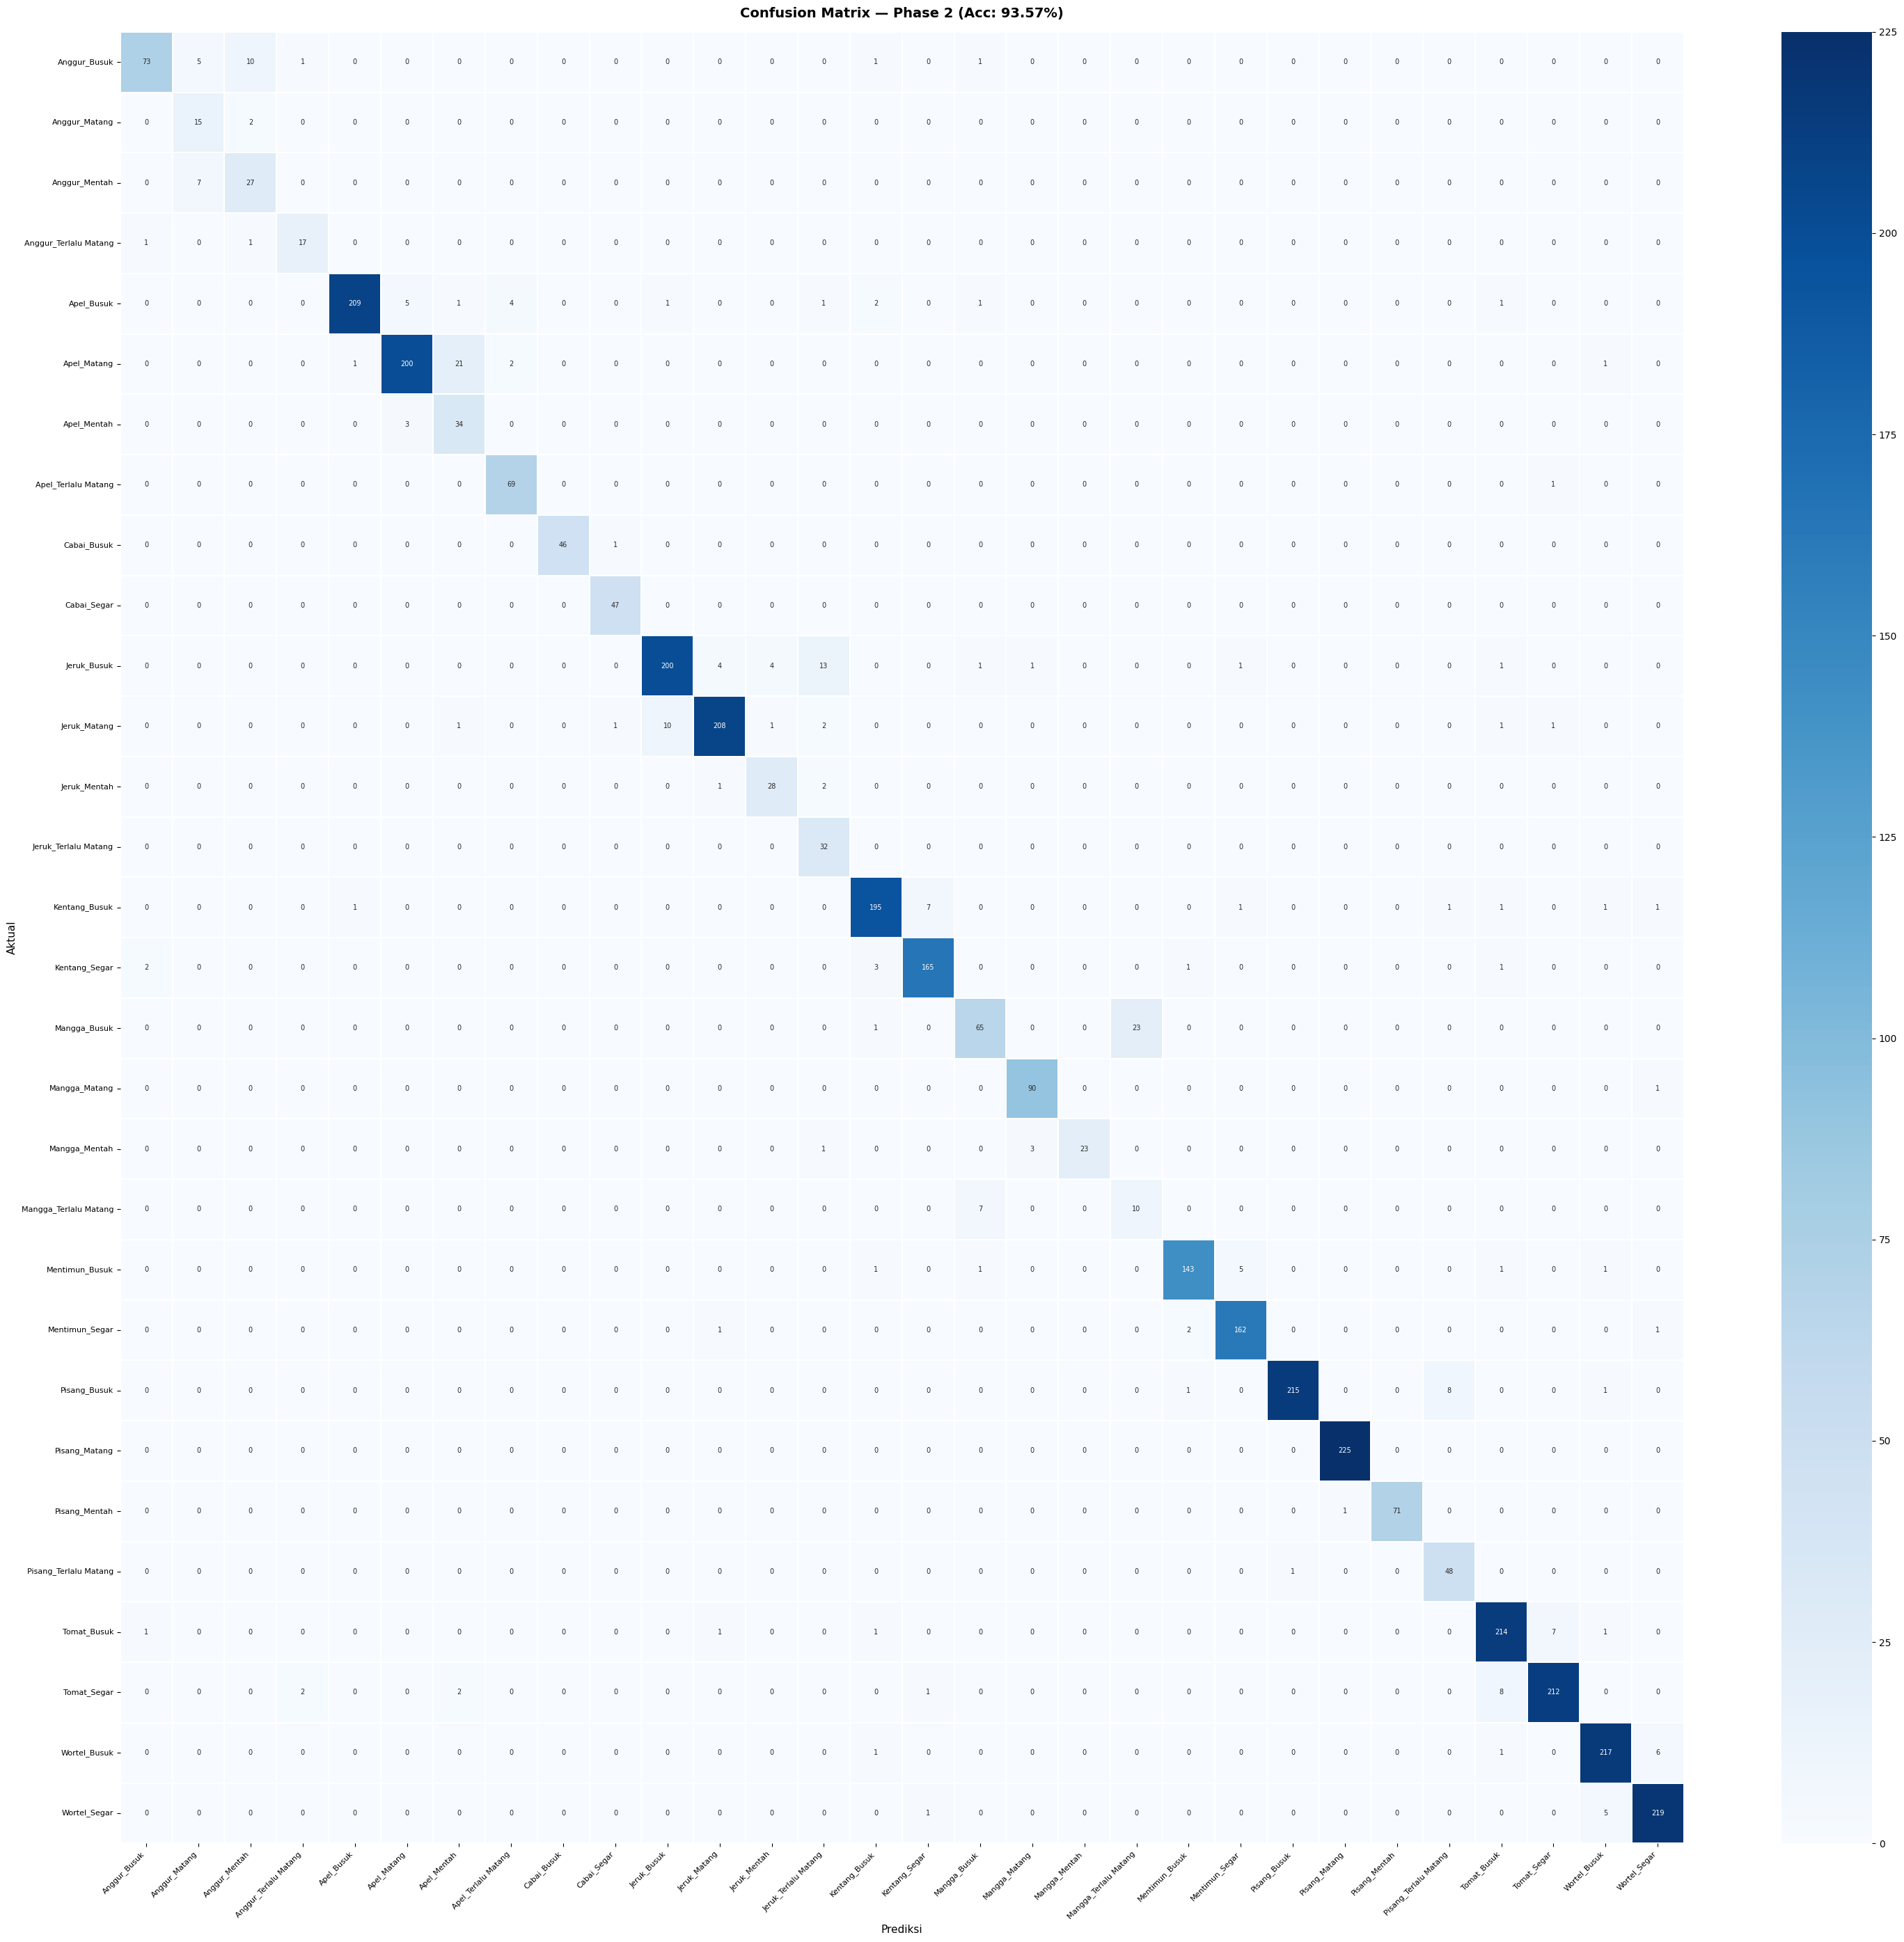

Tersimpan: ft_confusion_matrix.png


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(max(10, NUM_CLASSES), max(8, NUM_CLASSES - 2)))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=short_names, yticklabels=short_names,
    ax=ax, linewidths=0.3, annot_kws={'size': 7}
)
ax.set_xlabel('Prediksi', fontsize=11)
ax.set_ylabel('Aktual',   fontsize=11)
ax.set_title(f'Confusion Matrix — Phase 2 (Acc: {test_acc*100:.2f}%)',
             fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig('ft_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tersimpan: ft_confusion_matrix.png")

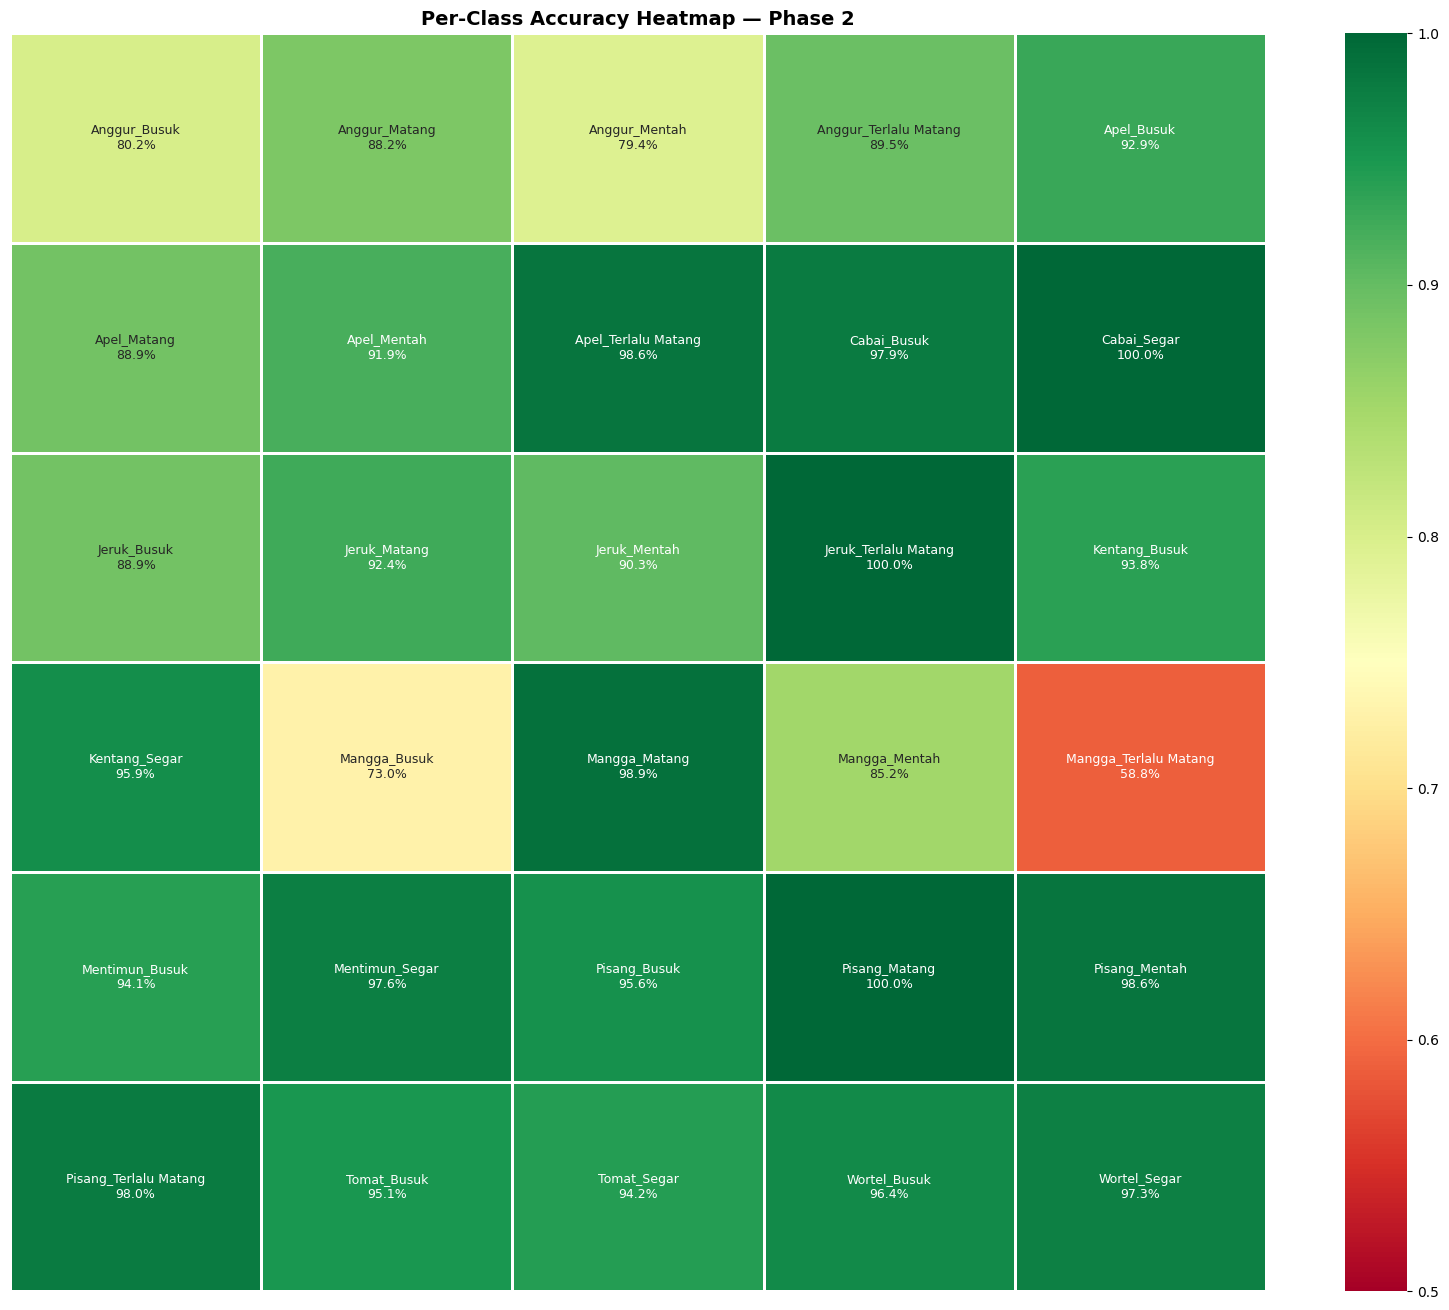

Tersimpan: ft_accuracy_heatmap.png


In [ ]:
# Per-Class Accuracy Heatmap
per_class_acc = cm.diagonal() / cm.sum(axis=1)

# Susun dalam grid untuk heatmap
n_cols = 5
n_rows = int(np.ceil(NUM_CLASSES / n_cols))
grid   = np.full((n_rows, n_cols), np.nan)
grid_labels = [[''] * n_cols for _ in range(n_rows)]

for i, (name, acc) in enumerate(zip(short_names, per_class_acc)):
    r, c = divmod(i, n_cols)
    grid[r, c]        = acc
    grid_labels[r][c] = f"{name}\n{acc*100:.1f}%"

fig, ax = plt.subplots(figsize=(16, n_rows * 2.2))
mask = np.isnan(grid)
sns.heatmap(
    grid, annot=grid_labels, fmt='', cmap='RdYlGn',
    vmin=0.5, vmax=1.0, mask=mask, linewidths=1,
    ax=ax, annot_kws={'size': 9}
)
ax.set_title('Per-Class Accuracy Heatmap — Phase 2', fontsize=14, fontweight='bold')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.savefig('ft_accuracy_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tersimpan: ft_accuracy_heatmap.png")

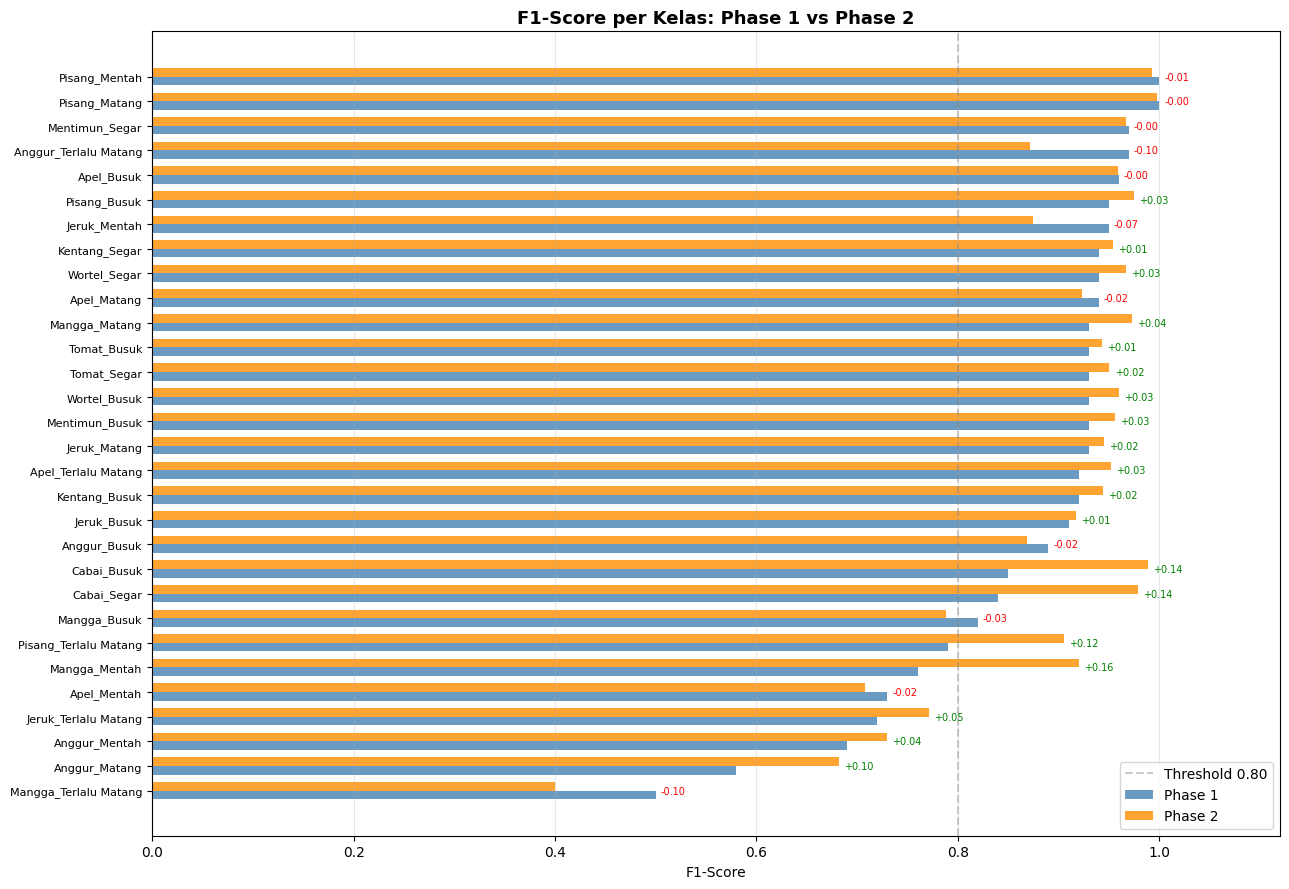

Tersimpan: ft_f1_comparison.png


In [ ]:
# F1-Score Comparison: Phase 1 vs Phase 2
# Nilai F1 Phase 1 (manual dari classification report Phase 1)
# Format: {class_name: f1_score}
F1_PHASE1 = {
    'Anggur_Busuk': 0.89, 'Anggur_Matang': 0.58, 'Anggur_Mentah': 0.69,
    'Anggur_Terlalu Matang': 0.97, 'Apel_Busuk': 0.96, 'Apel_Matang': 0.94,
    'Apel_Mentah': 0.73, 'Apel_Terlalu Matang': 0.92, 'Cabai_Busuk': 0.85,
    'Cabai_Segar': 0.84, 'Jeruk_Busuk': 0.91, 'Jeruk_Matang': 0.93,
    'Jeruk_Mentah': 0.95, 'Jeruk_Terlalu Matang': 0.72, 'Kentang_Busuk': 0.92,
    'Kentang_Segar': 0.94, 'Mangga_Busuk': 0.82, 'Mangga_Matang': 0.93,
    'Mangga_Mentah': 0.76, 'Mangga_Terlalu Matang': 0.50, 'Mentimun_Busuk': 0.93,
    'Mentimun_Segar': 0.97, 'Pisang_Busuk': 0.95, 'Pisang_Matang': 1.00,
    'Pisang_Mentah': 1.00, 'Pisang_Terlalu Matang': 0.79, 'Tomat_Busuk': 0.93,
    'Tomat_Segar': 0.93, 'Wortel_Busuk': 0.93, 'Wortel_Segar': 0.94
}

f1_p2 = [report_dict[n]['f1-score'] for n in short_names]
f1_p1 = [F1_PHASE1.get(n, np.nan)   for n in short_names]
delta  = [p2 - p1 if not np.isnan(p1) else 0
          for p2, p1 in zip(f1_p2, f1_p1)]

df_cmp = pd.DataFrame({
    'Kelas'  : short_names,
    'F1_P1'  : f1_p1,
    'F1_P2'  : f1_p2,
    'Delta'  : delta
}).sort_values('F1_P1')

fig, ax = plt.subplots(figsize=(13, 9))
y_pos  = np.arange(len(df_cmp))
h      = 0.35

bars1 = ax.barh(y_pos - h/2, df_cmp['F1_P1'], h, label='Phase 1', color='steelblue',  alpha=0.8)
bars2 = ax.barh(y_pos + h/2, df_cmp['F1_P2'], h, label='Phase 2', color='darkorange', alpha=0.8)

# Tambahkan label delta
for i, (p1, p2, d) in enumerate(zip(df_cmp['F1_P1'], df_cmp['F1_P2'], df_cmp['Delta'])):
    color = 'green' if d >= 0 else 'red'
    ax.text(max(p1, p2) + 0.005, y_pos[i], f'{d:+.2f}', va='center', fontsize=7, color=color)

ax.set_yticks(y_pos)
ax.set_yticklabels(df_cmp['Kelas'], fontsize=8)
ax.set_xlabel('F1-Score')
ax.set_xlim([0, 1.12])
ax.set_title('F1-Score per Kelas: Phase 1 vs Phase 2', fontsize=13, fontweight='bold')
ax.axvline(0.80, color='gray', ls='--', alpha=0.4, label='Threshold 0.80')
ax.legend(loc='lower right')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('ft_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tersimpan: ft_f1_comparison.png")

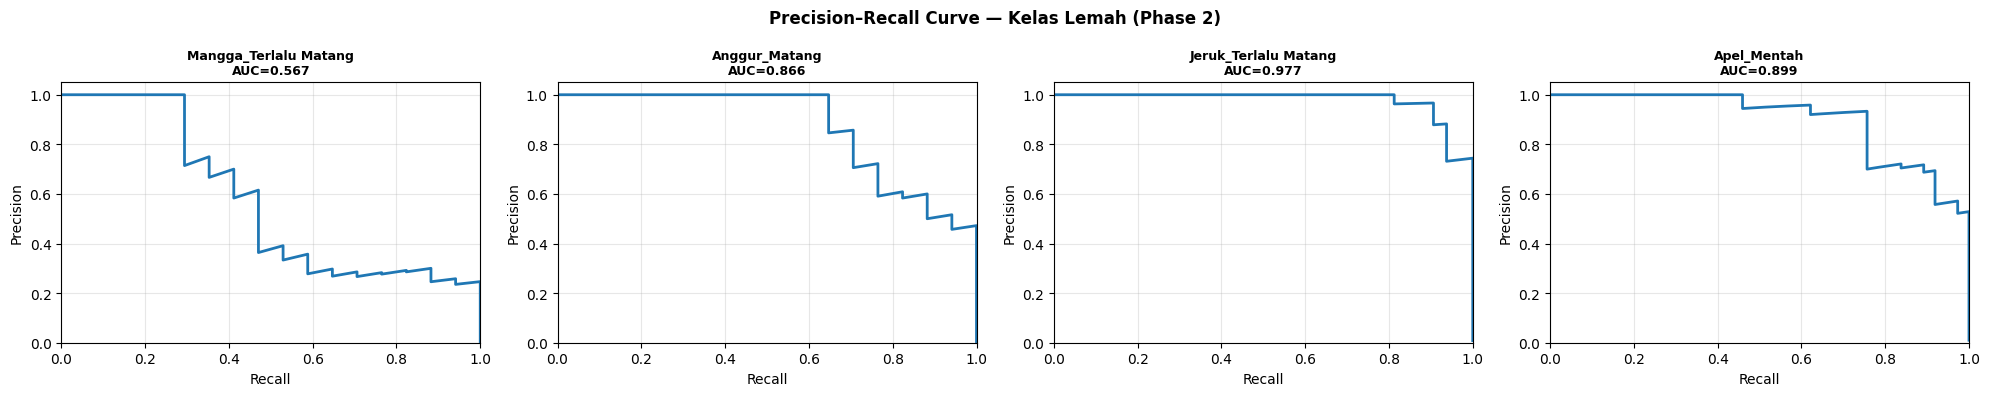

Tersimpan: ft_pr_curve_weak.png


In [ ]:
# Precision–Recall per kelas (kelas lemah)
WEAK_CLASSES_P1 = ['Mangga_Terlalu Matang', 'Anggur_Matang',
                   'Jeruk_Terlalu Matang',  'Apel_Mentah']

weak_indices = [short_names.index(c) for c in WEAK_CLASSES_P1 if c in short_names]

from sklearn.preprocessing import label_binarize
y_true_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))

fig, axes = plt.subplots(1, len(weak_indices), figsize=(5 * len(weak_indices), 4))
if len(weak_indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, weak_indices):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, idx], y_pred_proba[:, idx])
    pr_auc = auc(recall, precision)
    ax.plot(recall, precision, lw=2)
    ax.set_title(f"{short_names[idx]}\nAUC={pr_auc:.3f}", fontsize=9, fontweight='bold')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3)

fig.suptitle('Precision–Recall Curve — Kelas Lemah (Phase 2)', fontweight='bold')
plt.tight_layout()
plt.savefig('ft_pr_curve_weak.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tersimpan: ft_pr_curve_weak.png")

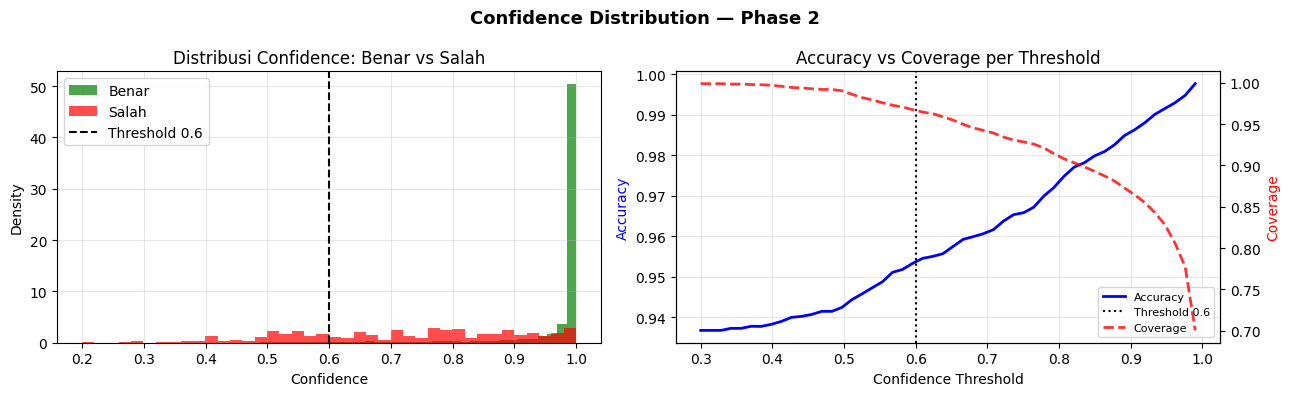

Tersimpan: ft_confidence_analysis.png


In [ ]:
# Confidence Distribution
max_conf   = np.max(y_pred_proba, axis=1)
is_correct = (y_pred == y_true)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Confidence Distribution — Phase 2', fontsize=13, fontweight='bold')

# Histogram confidence benar vs salah
ax = axes[0]
ax.hist(max_conf[is_correct],  bins=40, alpha=0.7, color='green',  label='Benar', density=True)
ax.hist(max_conf[~is_correct], bins=40, alpha=0.7, color='red',    label='Salah', density=True)
ax.axvline(CONFIDENCE_THRESHOLD, color='black', ls='--', label=f'Threshold {CONFIDENCE_THRESHOLD}')
ax.set_xlabel('Confidence')
ax.set_ylabel('Density')
ax.set_title('Distribusi Confidence: Benar vs Salah')
ax.legend()
ax.grid(True, alpha=0.3)

# Coverage vs Accuracy pada berbagai threshold
ax = axes[1]
thresholds = np.linspace(0.3, 0.99, 50)
coverages, accs_at_thresh = [], []
for t in thresholds:
    mask = max_conf >= t
    if mask.sum() == 0:
        coverages.append(0)
        accs_at_thresh.append(1.0)
    else:
        coverages.append(mask.mean())
        accs_at_thresh.append(is_correct[mask].mean())

ax2 = ax.twinx()
ax.plot(thresholds,  accs_at_thresh, 'b-',  label='Accuracy',  lw=2)
ax2.plot(thresholds, coverages,       'r--', label='Coverage', lw=2, alpha=0.8)
ax.axvline(CONFIDENCE_THRESHOLD, color='black', ls=':', label=f'Threshold {CONFIDENCE_THRESHOLD}')
ax.set_xlabel('Confidence Threshold')
ax.set_ylabel('Accuracy',  color='blue')
ax2.set_ylabel('Coverage', color='red')
ax.set_title('Accuracy vs Coverage per Threshold')
ax.grid(True, alpha=0.3)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('ft_confidence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tersimpan: ft_confidence_analysis.png")

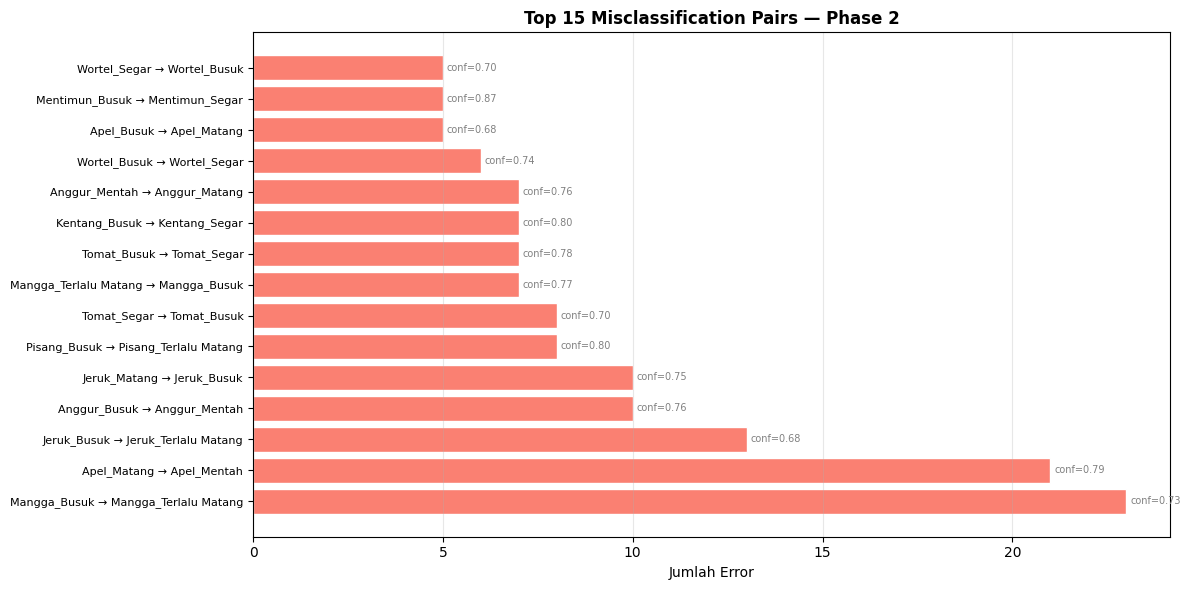

Tersimpan: ft_top_misclassifications.png


In [ ]:
# Top Misclassifications
errors_idx = np.where(y_pred != y_true)[0]
errors     = pd.DataFrame({
    'Aktual'    : [short_names[y_true[i]] for i in errors_idx],
    'Prediksi'  : [short_names[y_pred[i]] for i in errors_idx],
    'Confidence': [max_conf[i]            for i in errors_idx]
})

# Top 15 pasangan error paling sering
top_errors = (
    errors.groupby(['Aktual', 'Prediksi'])
    .agg(Count=('Confidence', 'count'), Avg_Conf=('Confidence', 'mean'))
    .reset_index()
    .sort_values('Count', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))
y_pos = np.arange(len(top_errors))
bars = ax.barh(y_pos, top_errors['Count'], color='salmon', edgecolor='white')

labels_err = [f"{r['Aktual']} → {r['Prediksi']}" for _, r in top_errors.iterrows()]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels_err, fontsize=8)
ax.set_xlabel('Jumlah Error')
ax.set_title('Top 15 Misclassification Pairs — Phase 2', fontweight='bold')

for bar, conf in zip(bars, top_errors['Avg_Conf']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'conf={conf:.2f}', va='center', fontsize=7, color='gray')

ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('ft_top_misclassifications.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tersimpan: ft_top_misclassifications.png")

## 8. Analisis Out-of-Scope Detection

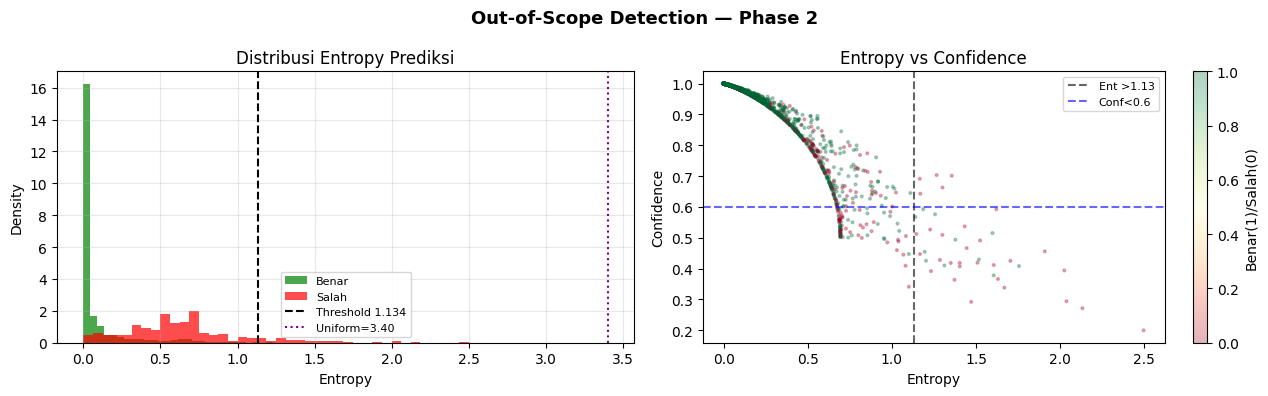

Tersimpan: ft_threshold_analysis.png

  Ditolak (conf < 0.6)  : 122 (3.3%)
  Ditolak (ent  > 1.134) : 41  (1.1%)
  Ditolak (gabungan)          : 127 (3.4%)


In [ ]:
# Threshold Analysis (Confidence + Entropy)
entropy_vals = -np.sum(y_pred_proba * np.log(y_pred_proba + 1e-9), axis=1)
uniform_ent  = np.log(NUM_CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Out-of-Scope Detection — Phase 2', fontsize=13, fontweight='bold')

# Entropy distribution
ax = axes[0]
ax.hist(entropy_vals[is_correct],  bins=40, alpha=0.7, color='green', label='Benar', density=True)
ax.hist(entropy_vals[~is_correct], bins=40, alpha=0.7, color='red',   label='Salah', density=True)
ax.axvline(ENTROPY_THRESHOLD, color='black', ls='--', label=f'Threshold {ENTROPY_THRESHOLD:.3f}')
ax.axvline(uniform_ent,       color='purple', ls=':',  label=f'Uniform={uniform_ent:.2f}')
ax.set_xlabel('Entropy')
ax.set_ylabel('Density')
ax.set_title('Distribusi Entropy Prediksi')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Scatter: entropy vs confidence
ax = axes[1]
sc = ax.scatter(entropy_vals, max_conf, c=is_correct.astype(int),
                cmap='RdYlGn', alpha=0.3, s=4)
ax.axvline(ENTROPY_THRESHOLD,    color='black', ls='--', alpha=0.6, label=f'Ent >{ENTROPY_THRESHOLD:.2f}')
ax.axhline(CONFIDENCE_THRESHOLD, color='blue',  ls='--', alpha=0.6, label=f'Conf<{CONFIDENCE_THRESHOLD}')
ax.set_xlabel('Entropy')
ax.set_ylabel('Confidence')
ax.set_title('Entropy vs Confidence')
ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label='Benar(1)/Salah(0)')

plt.tight_layout()
plt.savefig('ft_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tersimpan: ft_threshold_analysis.png")

# Statistik
rejected_conf = (max_conf < CONFIDENCE_THRESHOLD).sum()
rejected_ent  = (entropy_vals > ENTROPY_THRESHOLD).sum()
rejected_both = ((max_conf < CONFIDENCE_THRESHOLD) | (entropy_vals > ENTROPY_THRESHOLD)).sum()
print(f"\n  Ditolak (conf < {CONFIDENCE_THRESHOLD})  : {rejected_conf:,} ({rejected_conf/len(y_true)*100:.1f}%)")
print(f"  Ditolak (ent  > {ENTROPY_THRESHOLD:.3f}) : {rejected_ent:,}  ({rejected_ent/len(y_true)*100:.1f}%)")
print(f"  Ditolak (gabungan)          : {rejected_both:,} ({rejected_both/len(y_true)*100:.1f}%)")

## 9. Export Model Phase 2

In [ ]:
# Simpan model Keras & TFLite
os.makedirs('tflite_ft', exist_ok=True)
os.makedirs('saved_model_ft', exist_ok=True)

# Keras
model_best.save('vision_model_ft.keras')
print("Tersimpan: vision_model_ft.keras")

# SavedModel
try:
    model_best.export('saved_model_ft')
except AttributeError:
    model_best.save('saved_model_ft')
print("Tersimpan: saved_model_ft/")

# TFLite
converter = tf.lite.TFLiteConverter.from_saved_model('saved_model_ft')
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = 'tflite_ft/vision_model_ft.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize(tflite_path) / (1024**2)
print(f"Tersimpan: {tflite_path} ({size_mb:.1f} MB)")

# Label
with open('tflite_ft/label.txt', 'w') as f:
    for cls in CLASS_NAMES:
        f.write(cls + '\n')
print("Tersimpan: tflite_ft/label.txt")

Tersimpan: vision_model_ft.keras
Saved artifact at 'saved_model_ft'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 30), dtype=tf.float32, name=None)
Captures:
  139441016075472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139441016076624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139441016076432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139441016076048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139441016077200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139441016075664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139441016076816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139441016077584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139441016073552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139441016078160: TensorSpec(shape=(), dtype=tf.reso

In [ ]:
# Simpan metadata JSON
metadata = {
    'model_name'          : 'MobileNetV2_FT',
    'phase'               : 2,
    'input_size'          : [IMG_SIZE, IMG_SIZE, 3],
    'num_classes'         : NUM_CLASSES,
    'class_names'         : CLASS_NAMES,
    'test_accuracy'       : float(test_acc),
    'test_loss'           : float(test_loss),
    'phase1_accuracy'     : P1_ACC,
    'accuracy_gain'       : float(test_acc - P1_ACC),
    'confidence_threshold': CONFIDENCE_THRESHOLD,
    'entropy_threshold'   : float(ENTROPY_THRESHOLD),
    'unfreeze_layers'     : UNFREEZE_LAYERS,
    'learning_rate_ft'    : LR_FT,
    'epochs_ran'          : len(history_ft.history['accuracy']),
    'kondisi_map'         : {str(k): list(v) for k, v in KONDISI_MAP.items()},
    'nama_item_map'       : NAMA_ITEM_MAP,
    'output_format'       : '{nama_item}||{jenis_item}||{kondisi_fisik}',
    'output_example'      : "{'nama_item': 'Apel', 'jenis_item': 'Buah', 'kondisi_fisik': 'Matang', 'confidence': '96.1%'}"
}

with open('model_metadata_ft.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Tersimpan: model_metadata_ft.json")
print(json.dumps({k: v for k, v in metadata.items() if k != 'class_names'}, indent=2, ensure_ascii=False))

Tersimpan: model_metadata_ft.json
{
  "model_name": "MobileNetV2_FT",
  "phase": 2,
  "input_size": [
    224,
    224,
    3
  ],
  "num_classes": 30,
  "test_accuracy": 0.9357181191444397,
  "test_loss": 0.16935335099697113,
  "phase1_accuracy": 0.9193,
  "accuracy_gain": 0.01641811914443969,
  "confidence_threshold": 0.6,
  "entropy_threshold": 1.134,
  "unfreeze_layers": 30,
  "learning_rate_ft": 1e-05,
  "epochs_ran": 30,
  "kondisi_map": {
    "('buah', 'unripe')": [
      "Buah",
      "Mentah"
    ],
    "('buah', 'ripe')": [
      "Buah",
      "Matang"
    ],
    "('buah', 'overripe')": [
      "Buah",
      "Terlalu Matang"
    ],
    "('buah', 'rotten')": [
      "Buah",
      "Busuk"
    ],
    "('sayur', 'fresh')": [
      "Sayur",
      "Segar"
    ],
    "('sayur', 'rotten')": [
      "Sayur",
      "Busuk"
    ]
  },
  "nama_item_map": {
    "apple": "Apel",
    "banana": "Pisang",
    "mango": "Mangga",
    "orange": "Jeruk",
    "carrot": "Wortel",
    "potato": "Ken

## 10. Inference Helper & Quick Test

In [ ]:
# Fungsi prediksi dengan thresholding
def predict_image(img_path: str,
                  model=model_best,
                  conf_thresh=CONFIDENCE_THRESHOLD,
                  ent_thresh=ENTROPY_THRESHOLD) -> dict:
    """
    Prediksi satu gambar dengan confidence & entropy thresholding.

    Returns:
        dict dengan keys: nama_item, jenis_item, kondisi_fisik,
                          confidence, entropy, status
    """
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    proba    = model.predict(arr, verbose=0)[0]
    pred_idx = np.argmax(proba)
    conf     = float(proba[pred_idx])
    entropy  = float(-np.sum(proba * np.log(proba + 1e-9)))

    if conf < conf_thresh or entropy > ent_thresh:
        return {
            'nama_item'    : 'UNKNOWN',
            'jenis_item'   : 'UNKNOWN',
            'kondisi_fisik': 'UNKNOWN',
            'confidence'   : f'{conf*100:.1f}%',
            'entropy'      : f'{entropy:.3f}',
            'status'       : 'OUT_OF_SCOPE'
        }

    label_str  = idx2label[pred_idx]
    parts      = label_str.split('||')
    return {
        'nama_item'    : parts[0],
        'jenis_item'   : parts[1],
        'kondisi_fisik': parts[2],
        'confidence'   : f'{conf*100:.1f}%',
        'entropy'      : f'{entropy:.3f}',
        'status'       : 'OK'
    }

print("Fungsi predict_image() siap digunakan.")
print("Contoh: predict_image('/path/ke/gambar.jpg')")

Fungsi predict_image() siap digunakan.
Contoh: predict_image('/path/ke/gambar.jpg')


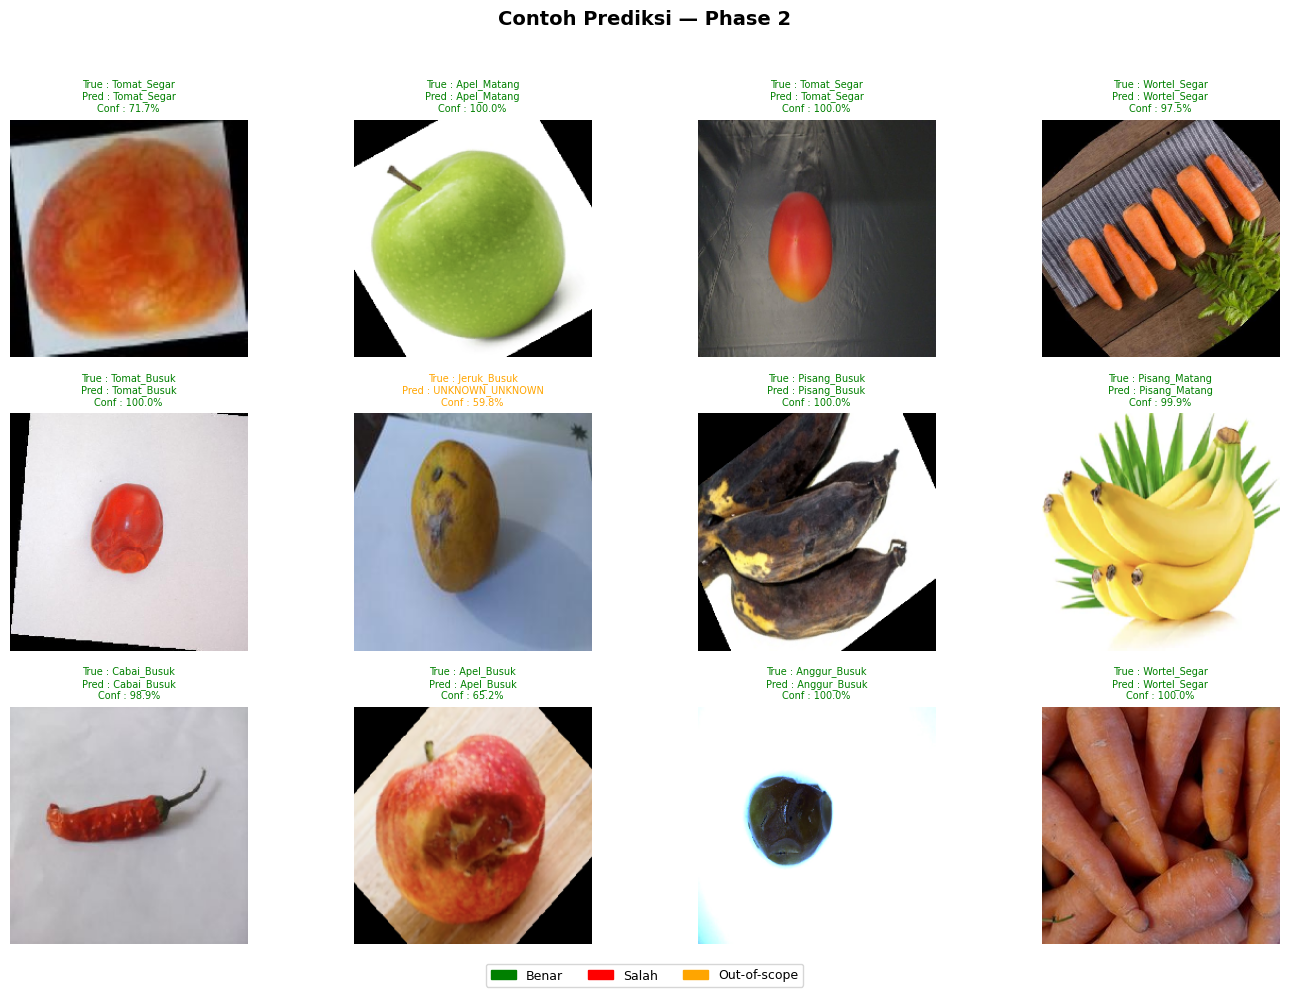

Tersimpan: ft_sample_predictions.png


In [ ]:
# Visual grid: prediksi beberapa contoh dari test set
N_SAMPLES = 12
sample_indices = random.sample(range(len(X_test)), N_SAMPLES)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Contoh Prediksi — Phase 2', fontsize=14, fontweight='bold')

for ax, idx in zip(axes.flatten(), sample_indices):
    img_path = X_test[idx]
    true_lbl = short_names[y_test_idx[idx]]
    result   = predict_image(img_path)

    pred_lbl = f"{result['nama_item']}_{result['kondisi_fisik']}"
    is_ok    = (result['status'] == 'OK')
    is_right = is_ok and (pred_lbl == true_lbl)

    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    ax.imshow(img)
    ax.set_title(
        f"True : {true_lbl}\nPred : {pred_lbl}\nConf : {result['confidence']}",
        fontsize=7,
        color='green' if is_right else ('orange' if not is_ok else 'red')
    )
    ax.axis('off')

# Legend
patches = [
    mpatches.Patch(color='green',  label='Benar'),
    mpatches.Patch(color='red',    label='Salah'),
    mpatches.Patch(color='orange', label='Out-of-scope'),
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('ft_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tersimpan: ft_sample_predictions.png")

In [ ]:
print(predict_image("test4.jpeg"))

{'nama_item': 'UNKNOWN', 'jenis_item': 'UNKNOWN', 'kondisi_fisik': 'UNKNOWN', 'confidence': '56.9%', 'entropy': '1.084', 'status': 'OUT_OF_SCOPE'}


## 11. Upload ke Drive & Ringkasan Akhir

In [ ]:
# Upload ke Drive
DRIVE_SAVE_DIR = '/content/drive/MyDrive/vision_model_ft'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

files_to_upload = [
    'vision_model_ft.keras',
    'model_metadata_ft.json',
    'tflite_ft/vision_model_ft.tflite',
    'tflite_ft/label.txt',
    'ft_training_curves.png',
    'ft_confusion_matrix.png',
    'ft_accuracy_heatmap.png',
    'ft_f1_comparison.png',
    'ft_confidence_analysis.png',
    'ft_threshold_analysis.png',
    'ft_top_misclassifications.png',
    'ft_sample_predictions.png',
    'logs/training_ft_log.csv',
]

for f in files_to_upload:
    if os.path.exists(f):
        dest = os.path.join(DRIVE_SAVE_DIR, os.path.basename(f))
        shutil.copy(f, dest)
        print(f"  ✓ {f} → Drive")
    else:
        print(f"  ✗ {f} tidak ditemukan, skip")

# Compress tflite folder
shutil.make_archive(os.path.join(DRIVE_SAVE_DIR, 'tflite_ft'), 'zip', 'tflite_ft')
print("  ✓ tflite_ft.zip → Drive")

  ✓ vision_model_ft.keras → Drive
  ✓ model_metadata_ft.json → Drive
  ✓ tflite_ft/vision_model_ft.tflite → Drive
  ✓ tflite_ft/label.txt → Drive
  ✓ ft_training_curves.png → Drive
  ✓ ft_confusion_matrix.png → Drive
  ✓ ft_accuracy_heatmap.png → Drive
  ✓ ft_f1_comparison.png → Drive
  ✓ ft_confidence_analysis.png → Drive
  ✓ ft_threshold_analysis.png → Drive
  ✓ ft_top_misclassifications.png → Drive
  ✓ ft_sample_predictions.png → Drive
  ✓ logs/training_ft_log.csv → Drive
  ✓ tflite_ft.zip → Drive


In [ ]:
# Ringkasan Akhir
print("=" * 65)
print("RINGKASAN AKHIR — PHASE 2 FINE-TUNING")
print("=" * 65)
print(f"  Model          : MobileNetV2 (unfreeze {UNFREEZE_LAYERS} layer terakhir)")
print(f"  Input          : {IMG_SIZE}×{IMG_SIZE}×3")
print(f"  Total kelas    : {NUM_CLASSES}")
print(f"  Train          : {len(X_train):,}")
print(f"  Val            : {len(X_val):,}")
print(f"  Test           : {len(X_test):,}")
print()
print(f"  Phase 1 Accuracy : {P1_ACC*100:.2f}%")
print(f"  Phase 2 Accuracy : {test_acc*100:.2f}%   ({delta_acc:+.2f}%)")
print(f"  Phase 1 Loss     : {P1_LOSS:.4f}")
print(f"  Phase 2 Loss     : {test_loss:.4f}   ({delta_loss:+.4f})")
print()
print(f"  Epochs ran     : {len(history_ft.history['accuracy'])}")
print(f"  LR Fine-Tuning : {LR_FT}")
print(f"  Conf threshold : {CONFIDENCE_THRESHOLD}")
print(f"  Entropy thresh : {ENTROPY_THRESHOLD:.3f} (uniform={np.log(NUM_CLASSES):.2f})")
print()
print("File output:")
print("  vision_model_ft.keras            → model Keras Phase 2")
print("  tflite_ft/vision_model_ft.tflite → untuk mobile")
print("  tflite_ft/label.txt              → daftar kelas")
print("  model_metadata_ft.json           → metadata & threshold")
print("  ft_training_curves.png")
print("  ft_confusion_matrix.png")
print("  ft_accuracy_heatmap.png")
print("  ft_f1_comparison.png             → perbandingan Phase 1 vs 2")
print("  ft_confidence_analysis.png")
print("  ft_threshold_analysis.png")
print("  ft_top_misclassifications.png")
print("  ft_sample_predictions.png")
print("  logs/training_ft_log.csv")
print("=" * 65)

RINGKASAN AKHIR — PHASE 2 FINE-TUNING
  Model          : MobileNetV2 (unfreeze 30 layer terakhir)
  Input          : 224×224×3
  Total kelas    : 30
  Train          : 17,350
  Val            : 3,718
  Test           : 3,718

  Phase 1 Accuracy : 91.93%
  Phase 2 Accuracy : 93.57%   (+1.64%)
  Phase 1 Loss     : 0.2659
  Phase 2 Loss     : 0.1694   (-0.0965)

  Epochs ran     : 30
  LR Fine-Tuning : 1e-05
  Conf threshold : 0.6
  Entropy thresh : 1.134 (uniform=3.40)

File output:
  vision_model_ft.keras            → model Keras Phase 2
  tflite_ft/vision_model_ft.tflite → untuk mobile
  tflite_ft/label.txt              → daftar kelas
  model_metadata_ft.json           → metadata & threshold
  ft_training_curves.png
  ft_confusion_matrix.png
  ft_accuracy_heatmap.png
  ft_f1_comparison.png             → perbandingan Phase 1 vs 2
  ft_confidence_analysis.png
  ft_threshold_analysis.png
  ft_top_misclassifications.png
  ft_sample_predictions.png
  logs/training_ft_log.csv
